In [141]:
# Data Processing
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns 

# Model Building
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression,LogisticRegression, Lasso
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Model Evaluation
from sklearn.metrics import mean_squared_error,mean_squared_error

import warnings
warnings.filterwarnings('ignore')



#Data Loading

In [142]:
athletes_df = pd.read_csv('athlete_events.csv')

regions_df = pd.read_csv('noc_regions.csv')

In [143]:
# lets check the glimpse of first five rows of athletes dataframe
athletes_df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [144]:
# lets check the glimpse of first five rows of regions dataframe
regions_df.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


In [145]:
# shape of dataframe
print('Shape of Athlete DF {}\n'.format(athletes_df.shape))
print('Shape of Regions DF {}'.format(regions_df.shape))

Shape of Athlete DF (271116, 15)

Shape of Regions DF (230, 3)


In [146]:
# lets merge athlete events and region based on NOC
df_merged = athletes_df.merge(regions_df,on='NOC',how='left')

In [147]:
df_merged.duplicated().sum()

np.int64(1385)

In [148]:
df_merged.drop_duplicates(inplace=True)

In [149]:
# Getting an overview of our data
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
 15  region  269361 non-null  object 
 16  notes   5035 non-null    object 
dtypes: float64(3), int64(2), object(12)
memory usage: 37.0+ MB


In [150]:
# summary statistics
df_merged.describe()

,ID,Age,Height,Weight,Year
count,269731.000000,260416.000000,210917.000000,208204.000000,269731.000000
mean,68264.949591,25.454776,175.338953,70.701778,1978.623073
std,39026.253843,6.163869,10.518507,14.349027,29.752055
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34655.500000,21.000000,168.000000,60.000000,1960.000000
50%,68233.000000,24.000000,175.000000,70.000000,1988.000000
75%,102111.000000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [151]:
# check for missing values
df_merged.isnull().sum()

ID             0
Name           0
Sex            0
Age         9315
Height     58814
Weight     61527
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     229959
region       370
notes     264696
dtype: int64

In [152]:
df_merged.duplicated().sum()

np.int64(0)

In [153]:
medal=pd.get_dummies(df_merged['Medal'], dtype=int)
medal.head(2)

,Bronze,Gold,Silver
0,0,0,0
1,0,0,0


In [154]:
df_merged=pd.concat([df_merged,medal],axis=1)

In [155]:
df_merged.duplicated(subset=['Team','NOC','Games','Year','Season','City','Sport','Event','Medal'])

0         False
1         False
2         False
3         False
4         False
          ...  
271111     True
271112     True
271113     True
271114     True
271115     True
Length: 269731, dtype: bool

In [156]:
df=df_merged.drop_duplicates(subset=['Team','NOC','Games','Year','Season','City','Sport','Event','Medal'])
df_merged

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Bronze,Gold,Silver
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN,0,0,0
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,0,0,0
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN,0,0,0
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN,0,1,0
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,Poland,NaN,0,0,0
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,Poland,NaN,0,0,0
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,Poland,NaN,0,0,0
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,Poland,NaN,0,0,0


In [157]:
df_merged=df_merged.drop_duplicates(subset=['Team','NOC','Games','Year','Season','City','Sport','Event','Medal'])

In [158]:
medals=df_merged.groupby('NOC')[['Gold', 'Silver', 'Bronze']].sum().sort_values('Gold', ascending=False).reset_index()
medals

,NOC,Gold,Silver,Bronze
0,USA,1131,901,792
1,URS,471,373,353
2,GER,321,345,341
3,GBR,289,321,312
4,FRA,265,287,334
...,...,...,...,...
225,LAO,0,0,0
226,AHO,0,1,0
227,LBR,0,0,0
228,LCA,0,0,0


#Exploratory Data Analysis

In [159]:
country=df_merged['region'].dropna().unique().tolist()
country.sort()
country.insert(0,"overall")
country

['overall',
 'Afghanistan',
 'Albania',
 'Algeria',
 'American Samoa',
 'Andorra',
 'Angola',
 'Antigua',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Boliva',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czech Republic',
 'Democratic Republic of the Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Eritrea',
 'Estonia',
 'Ethiopia',
 'Fiji',
 'Finland',
 'France',
 'Gabon',
 'Gambia',
 'Georgia',
 'Germany',
 'Ghana',
 'Greece',
 'Grenada',
 'Guam',
 'Guatemala',
 'Gui

In [160]:
df_merged['region'].unique().shape

(206,)

In [161]:
year=df_merged['Year'].dropna().unique().tolist()
year.sort()
year.insert(0,"overall")
year

['overall',
 1896,
 1900,
 1904,
 1906,
 1908,
 1912,
 1920,
 1924,
 1928,
 1932,
 1936,
 1948,
 1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1994,
 1996,
 1998,
 2000,
 2002,
 2004,
 2006,
 2008,
 2010,
 2012,
 2014,
 2016]

In [162]:
df_merged=df_merged.drop('Name', axis=1)

In [163]:
df_merged['Height'] = df_merged.groupby(['Sport','Sex'])['Height'].transform(lambda x: x.fillna(x.median()))
df_merged['Weight'] = df_merged.groupby(['Sport','Sex'])['Weight'].transform(lambda x: x.fillna(x.median()))
df_merged['Age'] = df_merged.groupby(['Sport','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

In [164]:
#to fill height weight and age where 0 data available for particular sport+sex combo
df_merged[['Age', 'Height', 'Weight']] = df_merged[['Age', 'Height', 'Weight']].fillna(df_merged[['Age', 'Height', 'Weight']].median())

In [165]:
# Handle Medals
df_merged['Medal'].fillna("No Medal", inplace=True)

In [166]:
df_merged['Medal'].value_counts()

Medal
No Medal    105707
Bronze        6559
Gold          6201
Silver        6167
Name: count, dtype: int64

In [167]:
def details(year,country,df_merged):
    flag=0
    if year=="overall" and country=="overall":
        df=df_merged
    if year=="overall" and country!="overall":
        flag=1
        df=df_merged[df_merged['region']==country]
    if year!="overall" and country=="overall":
        df=df_merged[df_merged['Year']==int(year)]
    if year!="overall" and country!="overall":
        df=df_merged[(df_merged['region']==country) & (df_merged['Year']==int(year))]
    if flag==1:
        summary=df.groupby('Year')[['Gold', 'Silver', 'Bronze']].sum().sort_values('Year', ascending=True).reset_index()
    else:
        summary=df.groupby('NOC')[['Gold', 'Silver', 'Bronze']].sum().sort_values('Gold', ascending=False).reset_index()
    summary["total"]=summary['Gold']+summary['Silver']+summary['Bronze']
    print(summary)

In [168]:
details('2016',"USA",df_merged)

   NOC  Gold  Silver  Bronze  total
0  USA    46      37      38    121


In [169]:
details('overall',"India",df_merged)

    Year  Gold  Silver  Bronze  total
0   1900     0       2       0      2
1   1920     0       0       0      0
2   1924     1       0       0      1
3   1928     1       0       0      1
4   1932     1       0       0      1
5   1936     1       0       0      1
6   1948     1       0       0      1
7   1952     1       0       1      2
8   1956     1       0       0      1
9   1960     0       1       0      1
10  1964     1       0       0      1
11  1968     0       0       1      1
12  1972     0       0       1      1
13  1976     0       0       0      0
14  1980     1       0       0      1
15  1984     0       0       0      0
16  1988     0       0       0      0
17  1992     0       0       0      0
18  1996     0       0       1      1
19  1998     0       0       0      0
20  2000     0       0       1      1
21  2002     0       0       0      0
22  2004     0       1       0      1
23  2006     0       0       0      0
24  2008     1       0       2      3
25  2010    

In [170]:
details('2016',"overall",df_merged)

     NOC  Gold  Silver  Bronze  total
0    USA    46      37      38    121
1    GBR    27      23      17     67
2    CHN    26      18      26     70
3    RUS    19      17      20     56
4    GER    17      10      15     42
..   ...   ...     ...     ...    ...
202  IND     0       1       1      2
203  IRL     0       2       0      2
204  IRQ     0       0       0      0
205  ISL     0       0       0      0
206  ZIM     0       0       0      0

[207 rows x 5 columns]


In [171]:
df[df['Season'] == 'Summer']['Year'].unique().shape

(29,)

In [172]:
df[df['Season'] == 'Summer']['Year'].unique()

array([1992, 2012, 1920, 1900, 1932, 1952, 2000, 1996, 1912, 1924, 1948,
       2008, 2016, 2004, 1984, 1968, 1972, 1988, 1936, 1956, 1960, 1928,
       1976, 1980, 1964, 1906, 1904, 1908, 1896])

In [173]:
#IOC does not count 1906 in official Olympic Games.
df=df[df['Year'] != 1906]

In [174]:
df[df['Season'] == 'Summer']['Year'].unique().shape

(28,)

In [175]:
df[df['Season'] == 'Winter']['Year'].unique()

array([1988, 1992, 1994, 2002, 1980, 2014, 1998, 2006, 1960, 1964, 1984,
       1952, 1956, 2010, 1968, 1972, 1976, 1924, 1928, 1948, 1932, 1936])

In [176]:
df[df['Season'] == 'Winter']['Year'].unique().shape

(22,)

In [177]:
df['City'].unique()

array(['Barcelona', 'London', 'Antwerpen', 'Paris', 'Calgary',
       'Albertville', 'Lillehammer', 'Los Angeles', 'Salt Lake City',
       'Helsinki', 'Lake Placid', 'Sydney', 'Atlanta', 'Stockholm',
       'Sochi', 'Nagano', 'Torino', 'Beijing', 'Rio de Janeiro', 'Athina',
       'Squaw Valley', 'Innsbruck', 'Sarajevo', 'Mexico City', 'Munich',
       'Seoul', 'Berlin', 'Oslo', "Cortina d'Ampezzo", 'Melbourne',
       'Roma', 'Amsterdam', 'Montreal', 'Moskva', 'Tokyo', 'Vancouver',
       'Grenoble', 'Sapporo', 'Chamonix', 'St. Louis', 'Sankt Moritz',
       'Garmisch-Partenkirchen'], dtype=object)

In [178]:
df['Event'].unique().shape

(744,)

In [179]:
# Top 10 countries participated
top_10_countries = df['Team'].value_counts().nlargest(10)
top_10_countries

Team
United States    6830
Great Britain    4385
France           4369
Italy            3915
Canada           3752
Germany          3549
Australia        3329
Japan            3317
Sweden           3203
Hungary          2878
Name: count, dtype: int64

In [180]:
# winter olympic sports
winter_sports = df[df['Season'] == 'Winter'].Sport.unique()
winter_sports

array(['Speed Skating', 'Cross Country Skiing', 'Ice Hockey', 'Biathlon',
       'Alpine Skiing', 'Luge', 'Bobsleigh', 'Figure Skating',
       'Nordic Combined', 'Freestyle Skiing', 'Ski Jumping', 'Curling',
       'Snowboarding', 'Short Track Speed Skating', 'Skeleton',
       'Military Ski Patrol', 'Alpinism'], dtype=object)

In [181]:
# summer olympic sports
summer_sports = df[df['Season'] == 'Summer'].Sport.unique()
summer_sports

array(['Basketball', 'Judo', 'Football', 'Tug-Of-War', 'Athletics',
       'Swimming', 'Badminton', 'Sailing', 'Gymnastics',
       'Art Competitions', 'Handball', 'Weightlifting', 'Wrestling',
       'Water Polo', 'Hockey', 'Rowing', 'Fencing', 'Equestrianism',
       'Shooting', 'Boxing', 'Taekwondo', 'Cycling', 'Diving', 'Canoeing',
       'Tennis', 'Modern Pentathlon', 'Golf', 'Softball', 'Archery',
       'Volleyball', 'Synchronized Swimming', 'Table Tennis', 'Baseball',
       'Rhythmic Gymnastics', 'Rugby Sevens', 'Trampolining',
       'Beach Volleyball', 'Triathlon', 'Rugby', 'Lacrosse', 'Polo',
       'Cricket', 'Ice Hockey', 'Racquets', 'Motorboating', 'Croquet',
       'Figure Skating', 'Jeu De Paume', 'Roque', 'Basque Pelota',
       'Alpinism', 'Aeronautics'], dtype=object)

In [182]:
total_count = df.groupby("Season")[["Team", "NOC", "Event", "City", "Sport"]].nunique().reset_index()
total_count

,Season,Team,NOC,Event,City,Sport
0,Summer,1129,229,630,23,52
1,Winter,221,119,119,19,17


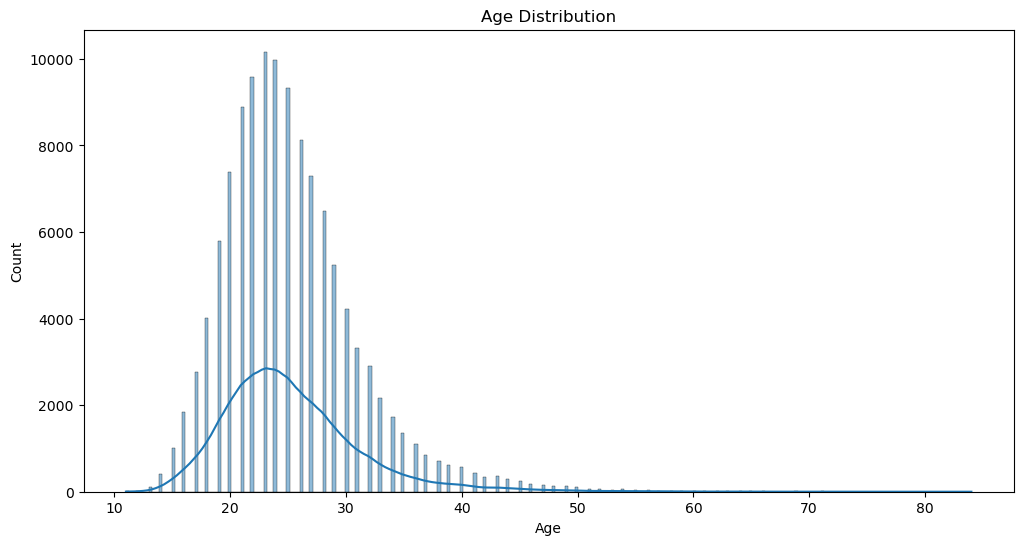

In [183]:
# Age distribution of the participants
plt.figure(figsize=(12, 6))
sns.histplot(df["Age"], kde=True)
plt.xlabel('Age')
plt.title('Age Distribution')
plt.show()

In [184]:
tidy = df.melt(id_vars='Season', 
                       var_name='Variable', 
                       value_name='Value')

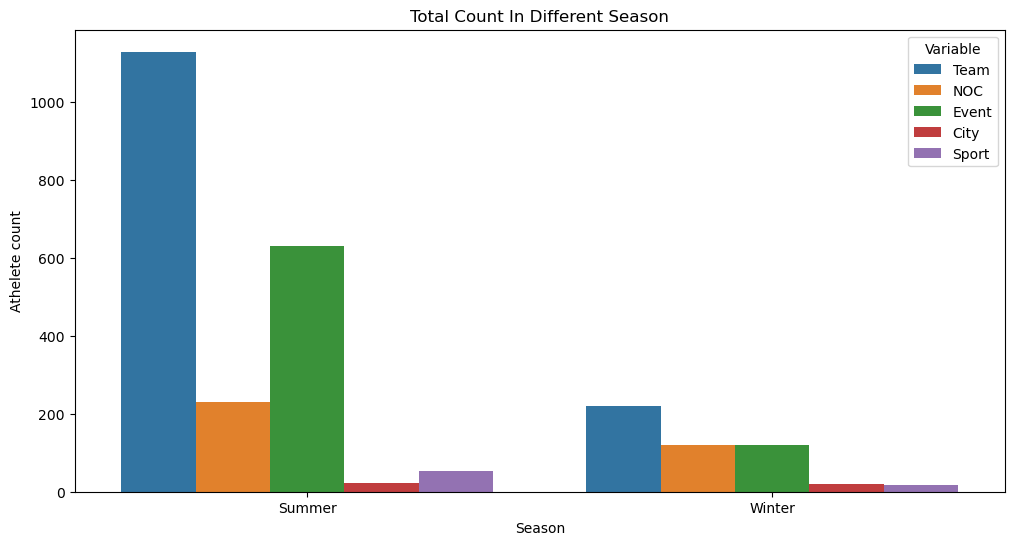

In [185]:
tidy = total_count.melt(id_vars='Season').rename(columns=str.title)

plt.subplots(figsize=(12, 6))
sns.barplot(x='Season', y='Value', hue='Variable', data=tidy)
plt.title('Total Count In Different Season')
plt.ylabel("Athelete count")
plt.show()

In [186]:
# male and female participants
gender_counts = df.Sex.value_counts()
gender_counts

Sex
M    88270
F    35677
Name: count, dtype: int64

#Since Inception of olympics, we have more number of male participants than female participants

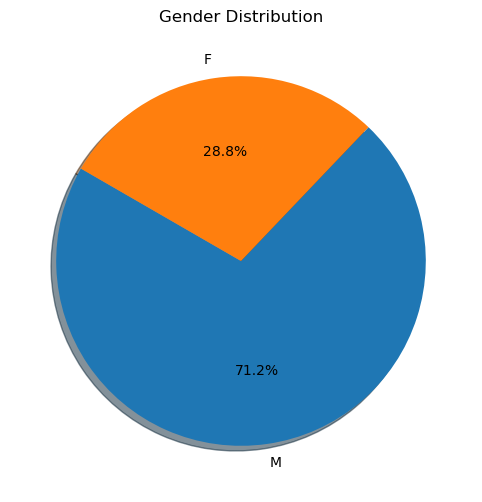

In [187]:
# pie chart for male and female participants
plt.figure(figsize=(12,6))
plt.pie(gender_counts,labels = gender_counts.index, autopct = '%1.1f%%',startangle=150,shadow=True )
plt.title('Gender Distribution')
plt.show()

<a id='section-3.6'></a>
<h3 style="color:#F20707;">Distribution According to Sex in both Season</h3>

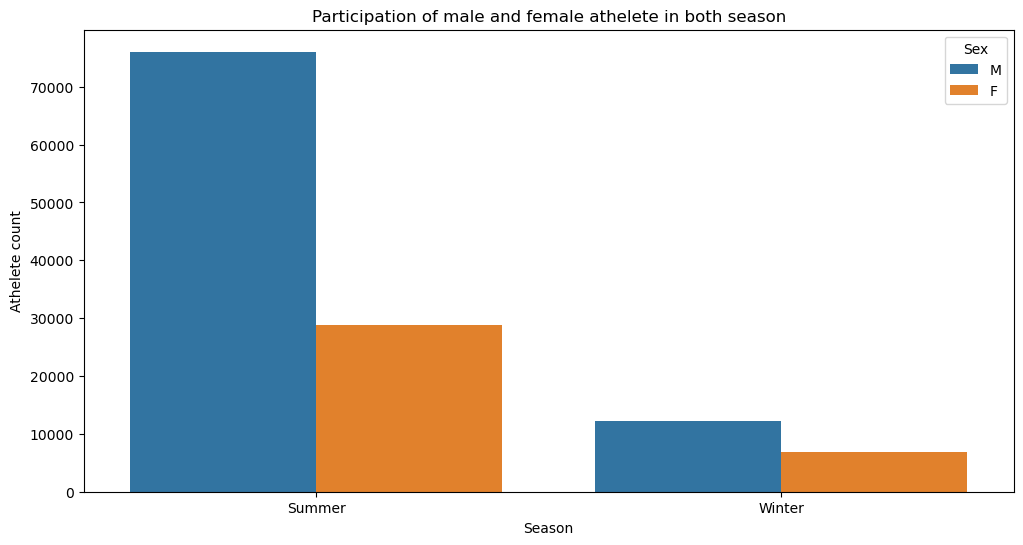

In [188]:
plt.figure(figsize=(12,6))
sns.countplot(x="Season", hue="Sex", data=df)
plt.title('Participation of male and female athelete in both season')
plt.ylabel("Athelete count")
plt.show()

In [189]:
# Total medals
df.Medal.value_counts()  #this

Medal
Bronze    6486
Gold      6127
Silver    6090
Name: count, dtype: int64

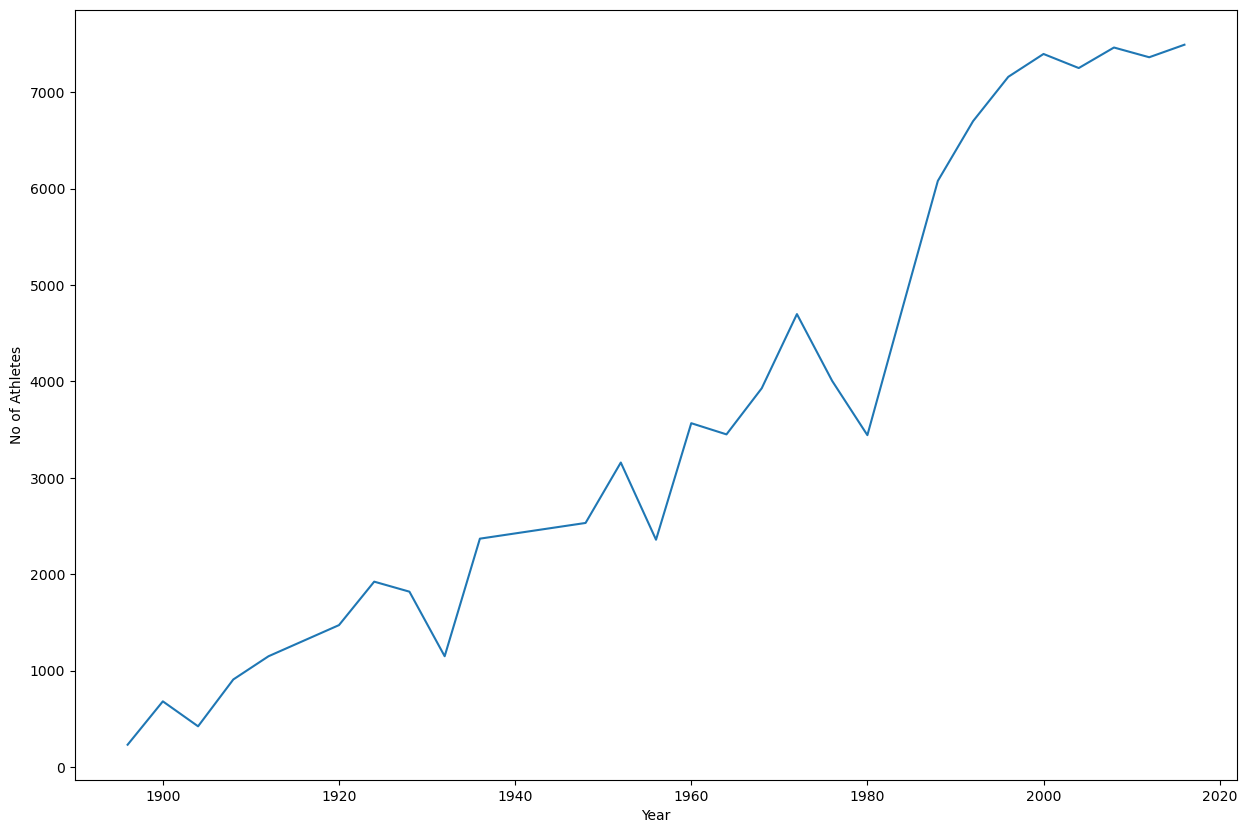

In [190]:
# Atheletes Participated in Summer Olympics
athletes_per_year = df[df['Season']=='Summer'].groupby('Year')['ID'].count().reset_index()

plt.figure(figsize=(15, 10))
sns.lineplot(data=athletes_per_year, x="Year", y="ID")
plt.xlabel('Year')
plt.ylabel('No of Athletes')
plt.show()

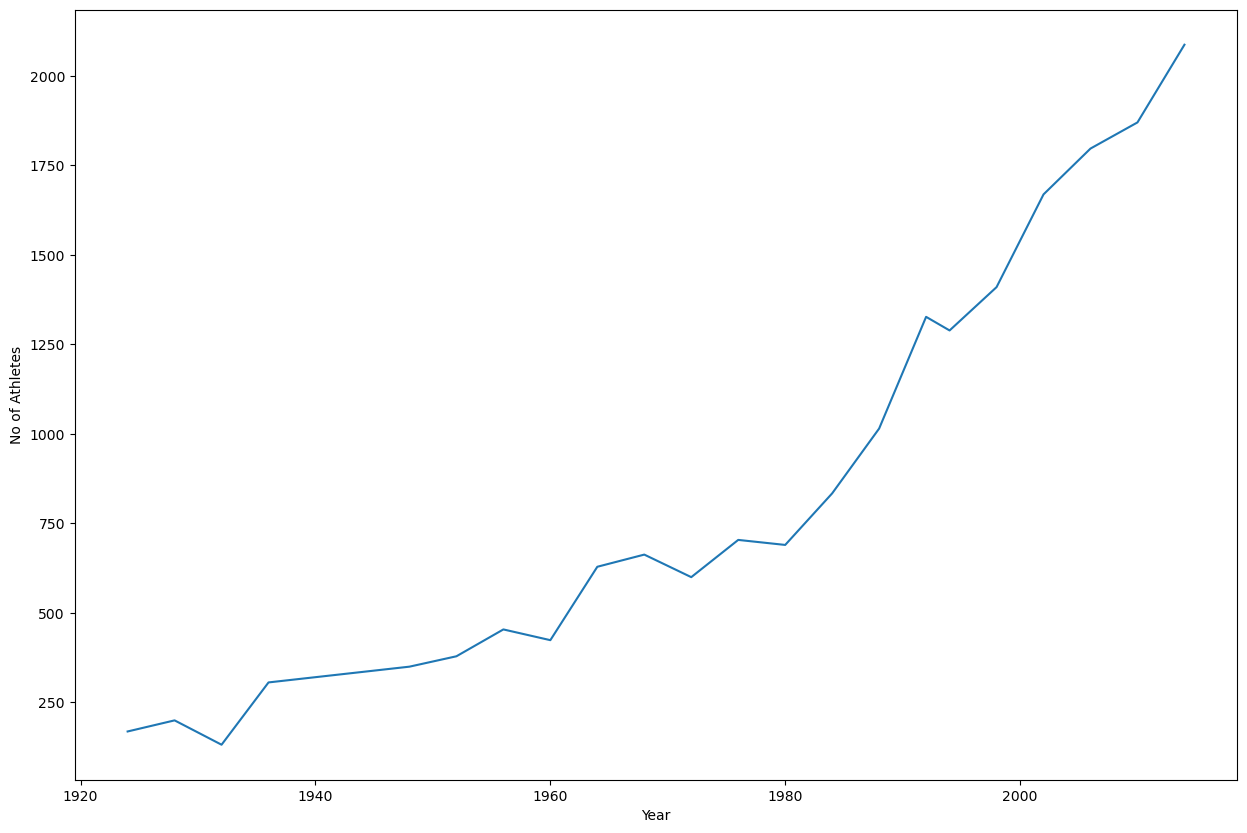

In [191]:
# Atheletes Participated in Winter Olympics
athletes_per_year = df[df['Season']=='Winter'].groupby('Year')['ID'].count().reset_index()

plt.figure(figsize=(15, 10))
sns.lineplot(data=athletes_per_year, x="Year", y="ID")
plt.xlabel('Year')
plt.ylabel('No of Athletes')
plt.show()

In [192]:
df['region'].unique().shape

(206,)

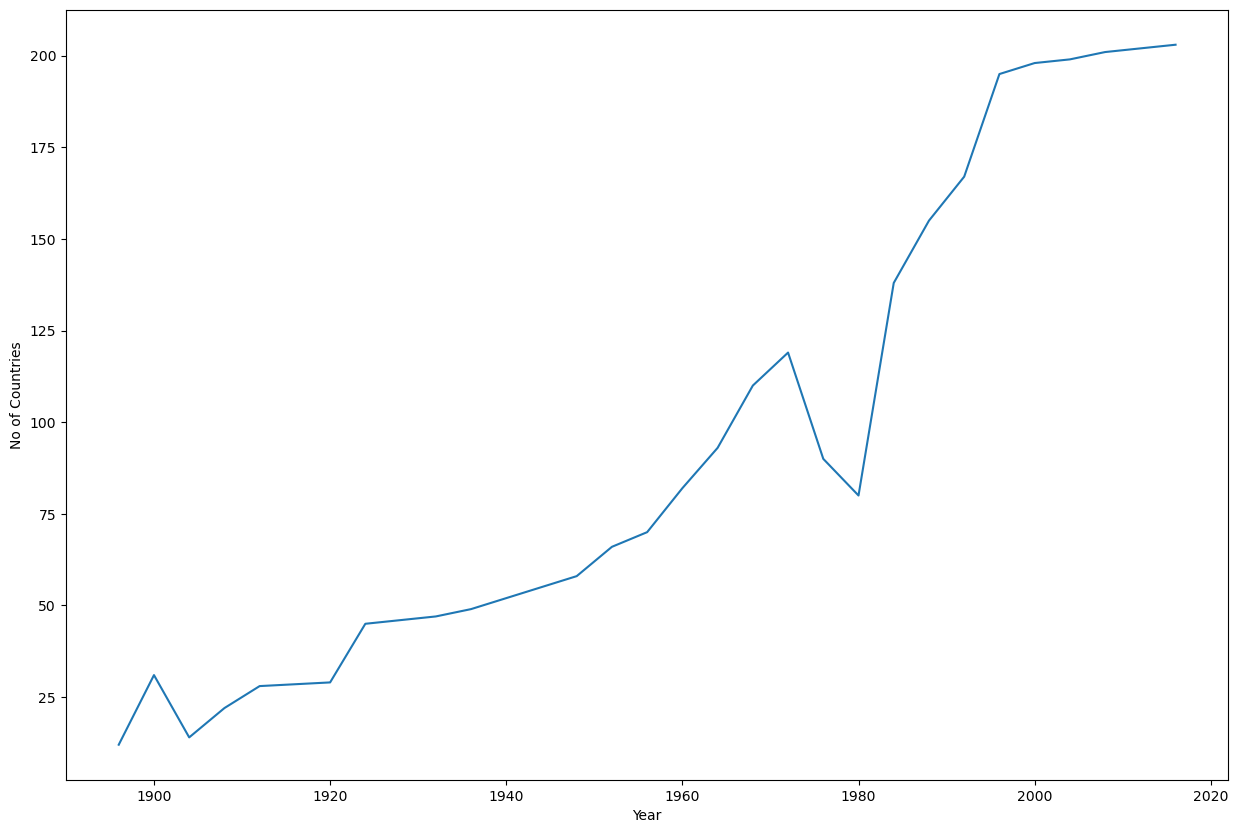

In [193]:
#countries participated over the years
countries_per_year = df[df['Season']=='Summer'].groupby('Year')['region'].nunique().reset_index()

plt.figure(figsize=(15, 10))
sns.lineplot(data=countries_per_year, x="Year", y="region")
plt.xlabel('Year')
plt.ylabel('No of Countries')
plt.show()

In [194]:
df['Event'].unique().shape

(744,)

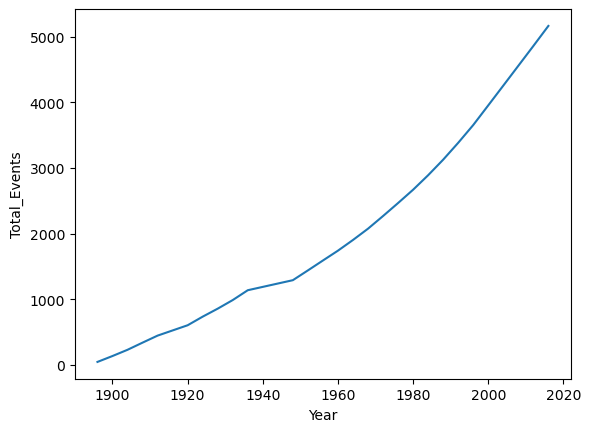

In [195]:
#events participated over the years
df_summer = df[df['Season']=='Summer']

events_over_time = (
    df_summer.sort_values('Year')
    .drop_duplicates(['Event', 'Year'])
    .groupby('Year')['Event']
    .nunique()
    .cumsum()
    .reset_index(name='Total_Events')
)

sns.lineplot(data=events_over_time, x='Year', y='Total_Events')
plt.show()

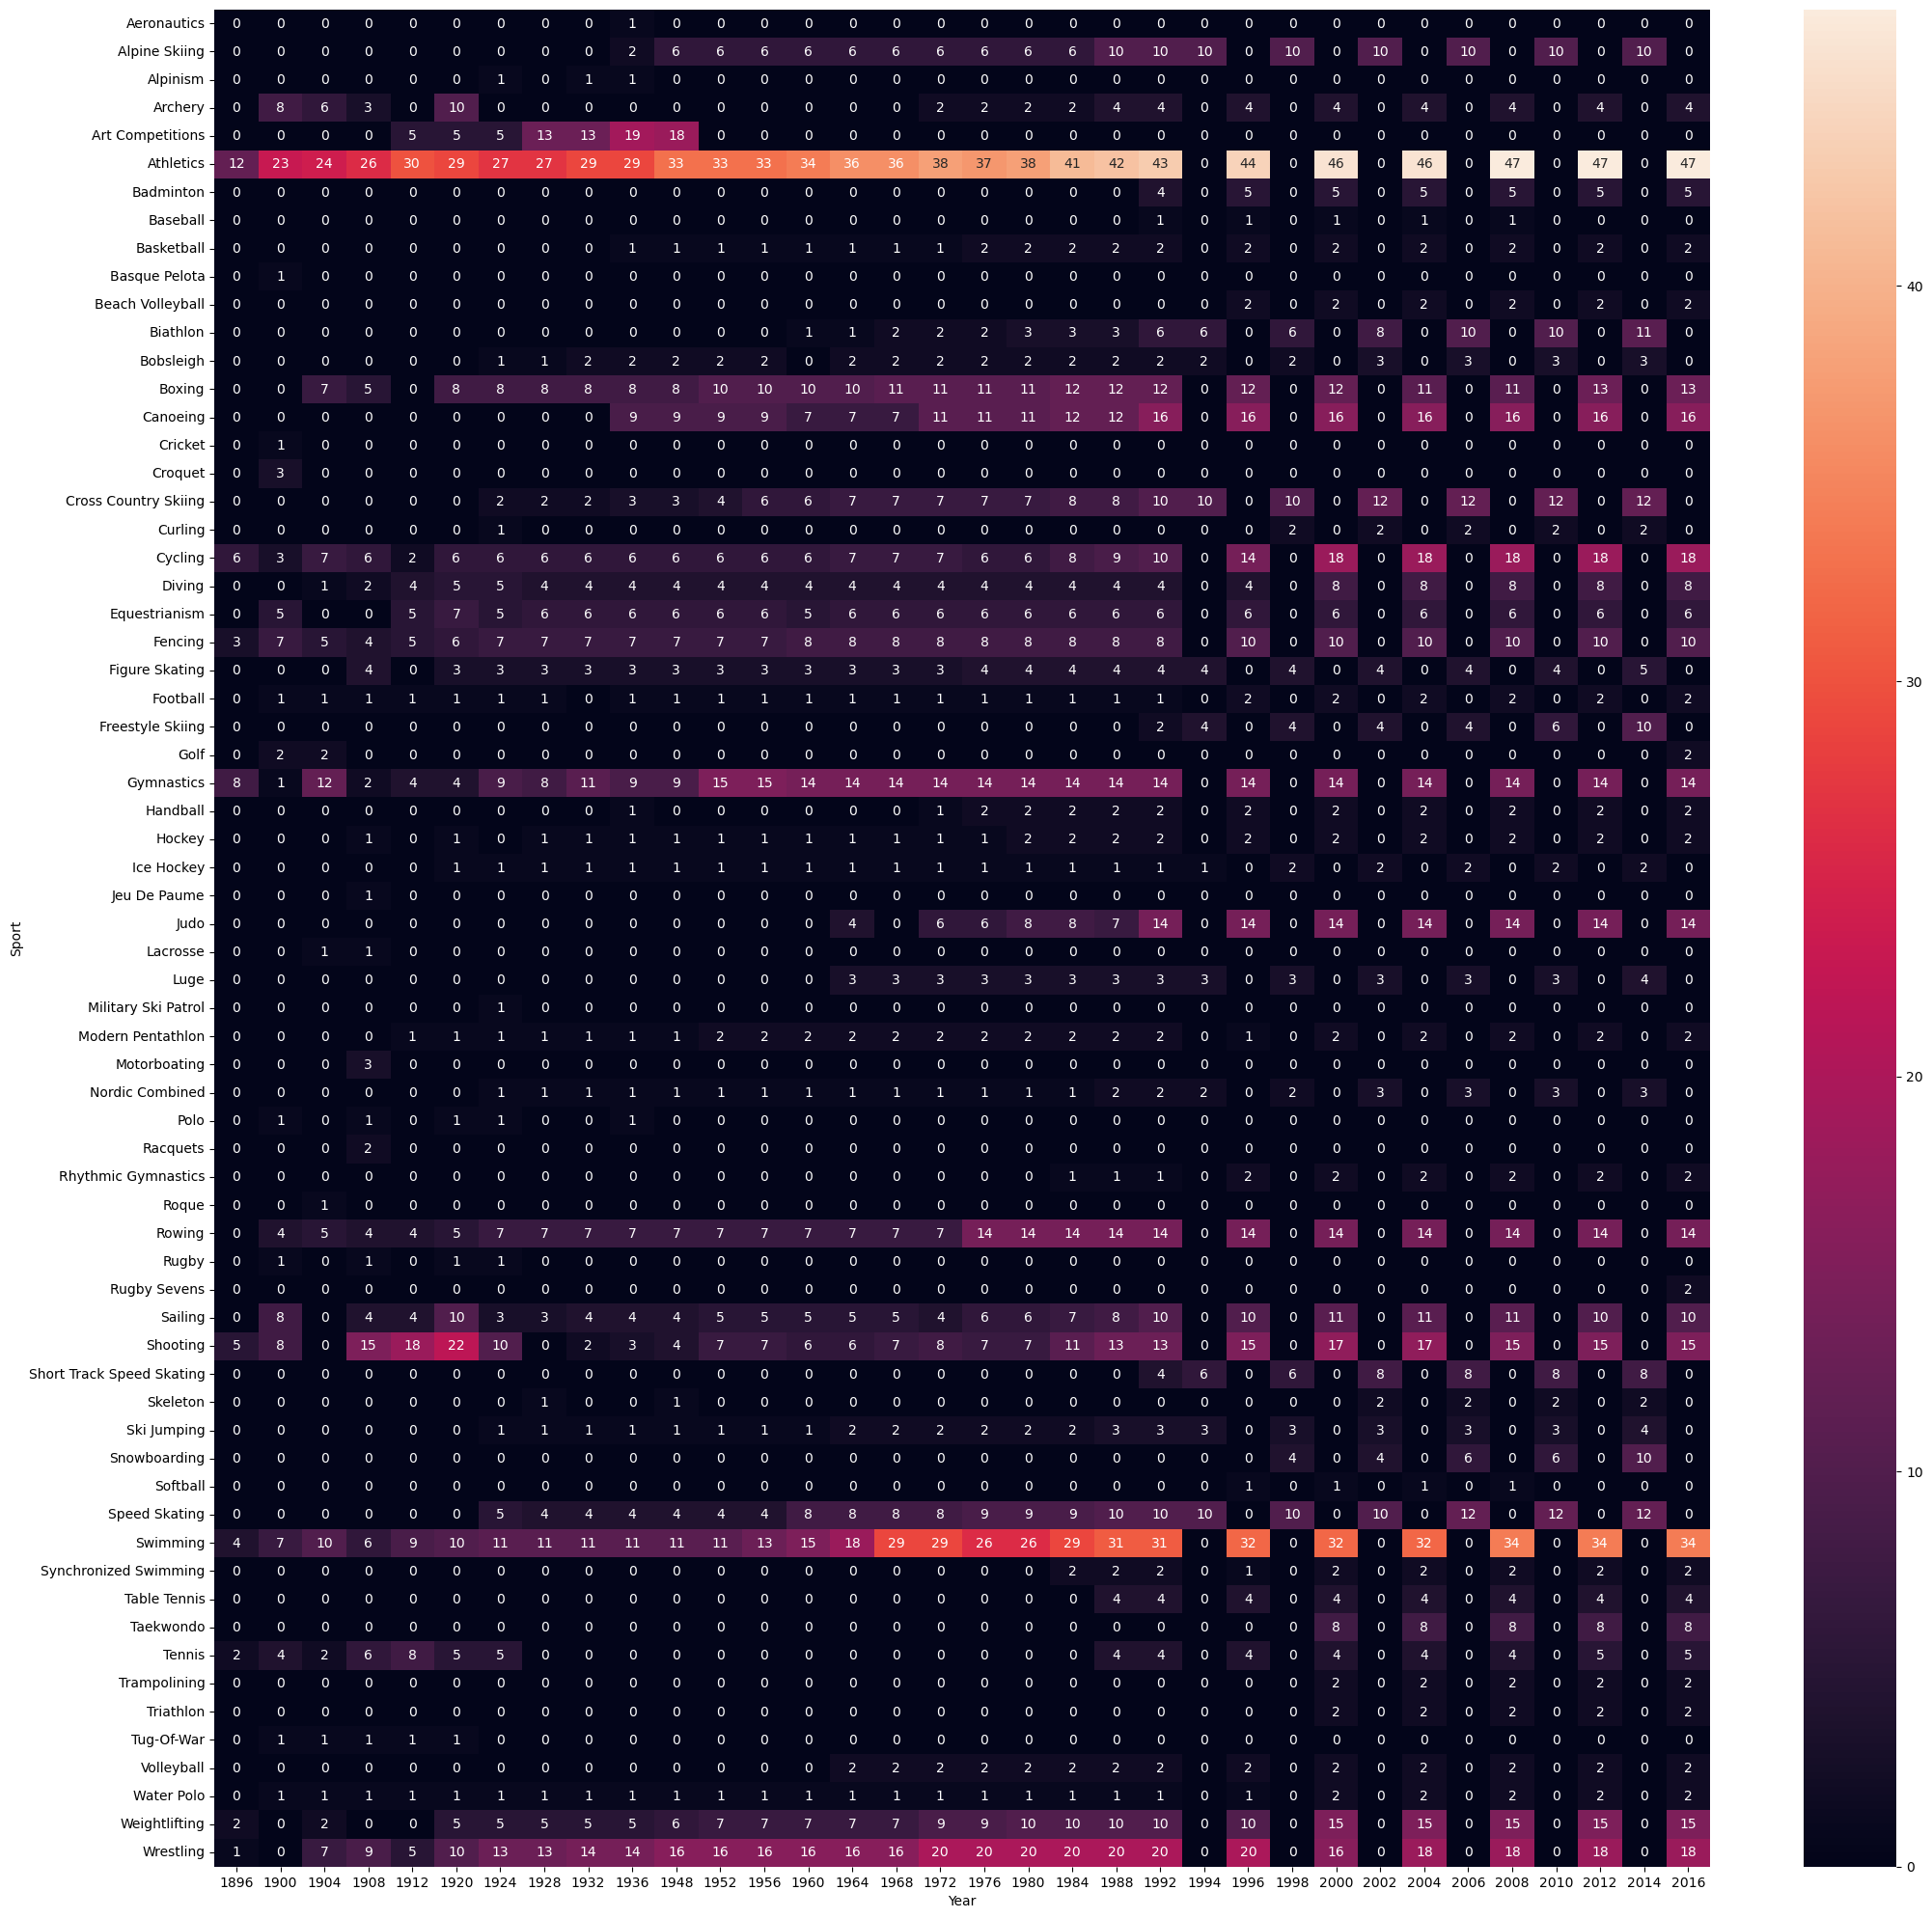

In [196]:
x=df.drop_duplicates(['Year','Sport','Event'])
plt.figure(figsize=(25, 25))

heatmap_data = (
    x.pivot_table(
        index='Sport',
        columns='Year',
        values='Event',
        aggfunc='count'
    )
    .fillna(0)
    .astype(int)
)

sns.heatmap(heatmap_data, annot=True)
plt.xlabel('Year')
plt.ylabel('Sport')
plt.show()

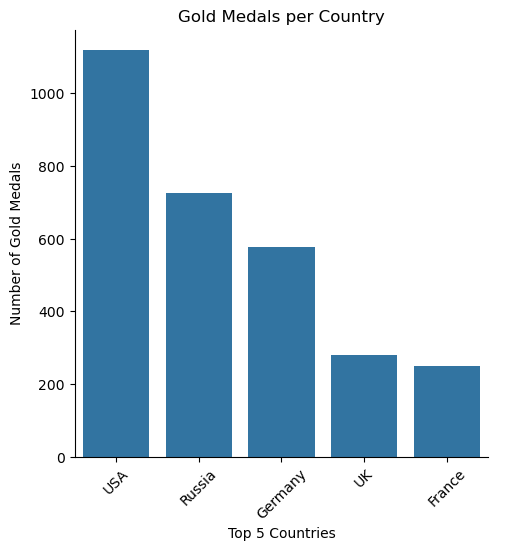

In [197]:
# Filter only Gold medals
gold_df = df[df['Medal'] == 'Gold']

# Count gold medals per region
totalGoldMedals = gold_df['region'].value_counts().reset_index()
totalGoldMedals.columns = ['region', 'GoldMedals']

# Plot
sns.catplot(
    x='region',
    y='GoldMedals',
    data=totalGoldMedals.head(5),
    kind='bar'
)

plt.xlabel('Top 5 Countries')
plt.ylabel('Number of Gold Medals')
plt.title('Gold Medals per Country')
plt.xticks(rotation=45)
plt.show()

In [198]:
# total number of female athletes in summer olympics
female_participants = df[(df['Sex'] == 'F') & (df['Season'] == 'Summer')][['Sex','Year']]
female_participants = female_participants.groupby('Year').count().reset_index()
female_participants.head()

,Year,Sex
0,1900,18
1,1904,9
2,1908,18
3,1912,39
4,1920,74


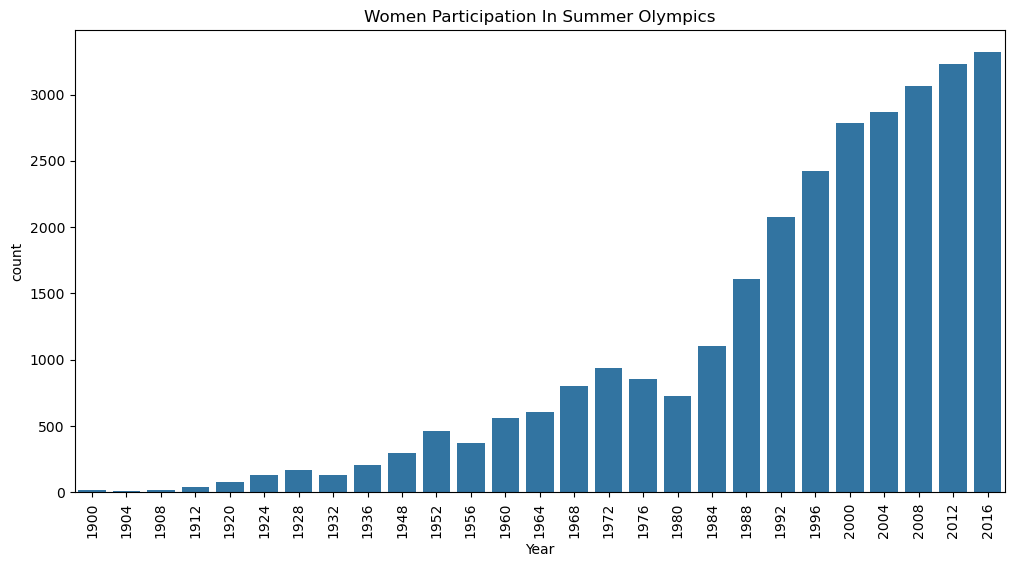

In [199]:
# female athletes in summer olympics
women_olympics = df[(df['Sex'] == 'F') & (df['Season'] == 'Summer')]

# count plot for women participation
plt.figure(figsize=(12,6))
sns.countplot(x='Year',data=women_olympics)
plt.title('Women Participation In Summer Olympics')
plt.xticks(rotation=90)
plt.show()

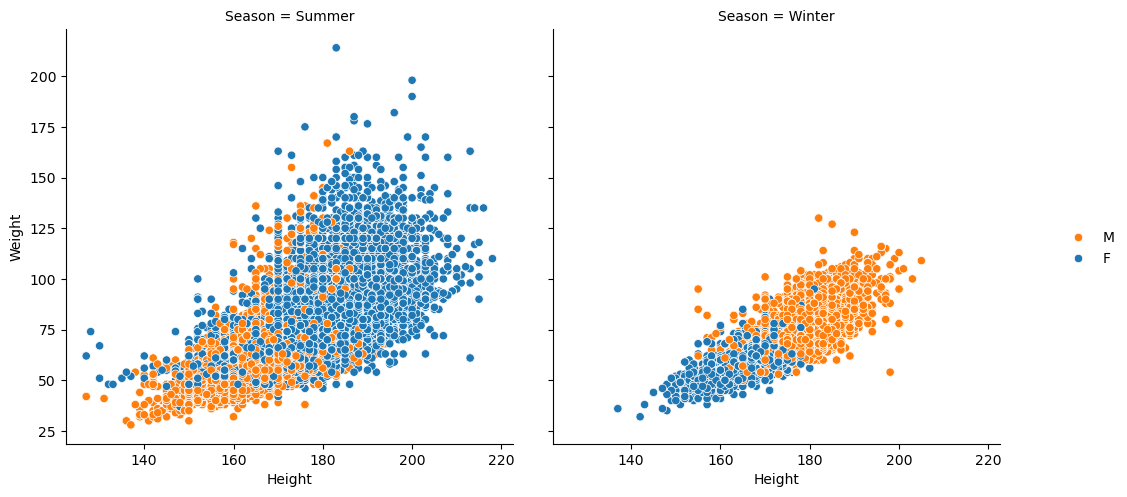

In [200]:
#Distribution of Height and Weight of Male and Female Athelete over Time in both Seasons
merged_df_cleaned = df_merged[(df_merged['Height'].notnull()) & (df_merged['Weight'].notnull())]

g = sns.FacetGrid(merged_df_cleaned,col="Season")
g.map(sns.scatterplot, "Height", "Weight","Sex")
g.add_legend()
fig = plt.gcf()
fig.set_size_inches(12, 6)
plt.show()

In [201]:
df_merged.duplicated(subset=['Team','NOC','Games','Year','Season','City','Sport','Event','Medal'])

0         False
1         False
2         False
3         False
4         False
          ...  
271095    False
271096    False
271097    False
271098    False
271099    False
Length: 124634, dtype: bool

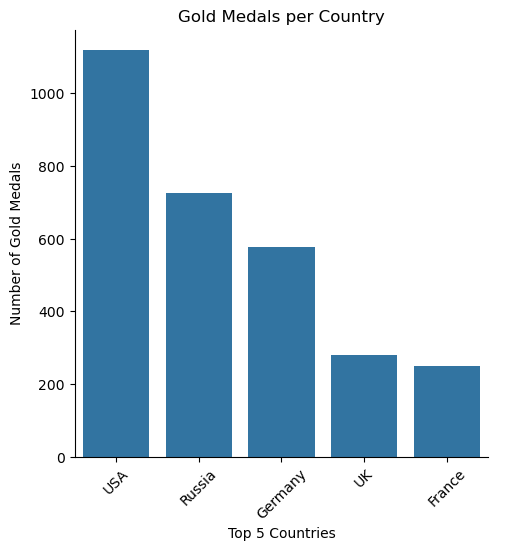

In [202]:
# Filter only Gold medals
gold_df = df[df['Medal'] == 'Gold']

# Count gold medals per region
totalGoldMedals = gold_df['region'].value_counts().reset_index()
totalGoldMedals.columns = ['region', 'GoldMedals']

# Plot
sns.catplot(
    x='region',
    y='GoldMedals',
    data=totalGoldMedals.head(5),
    kind='bar'
)

plt.xlabel('Top 5 Countries')
plt.ylabel('Number of Gold Medals')
plt.title('Gold Medals per Country')
plt.xticks(rotation=45)
plt.show()

In [203]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region', 'notes',
       'Bronze', 'Gold', 'Silver'],
      dtype='object')

In [204]:
# ---------------------------------------------------------
# 4. DATA AGGREGATION (Fixed Binning Logic)
# ---------------------------------------------------------
#country_df = df_merged.groupby(['region', 'Year']).agg({
#   'Age': 'mean', 
 #   'Height': 'mean', 
 #   'Weight': 'mean',
 #   'Gold': 'sum',
 #   'Silver': 'sum',
 #   'Bronze': 'sum'
#}).reset_index().dropna()
country_df = df.groupby(['region','Year']).agg({
    'ID': 'nunique',             # athlete count
    'Age': 'median',
    'Height': 'median',
    'Weight': 'median',
    'Gold': 'sum',
    'Silver': 'sum',
    'Bronze': 'sum'
}).reset_index()

# Rename columns
country_df.columns = [
    'region','Year','athlete_count',
    'age_median','height_median','weight_median',
    'Gold','Silver','Bronze'
]
# Total medals
country_df['Total_Medals'] = (
    country_df['Gold'] +
    country_df['Silver'] +
    country_df['Bronze']
)

# ---------------------------------------------------------
# 3. CREATE PAST (LAG) FEATURES
# ---------------------------------------------------------
country_df = country_df.sort_values(['region','Year'])
country_df['Gold_prev'] = country_df.groupby('region')['Gold'].shift(1)
country_df['Silver_prev'] = country_df.groupby('region')['Silver'].shift(1)
country_df['Bronze_prev'] = country_df.groupby('region')['Bronze'].shift(1)
country_df['Total_prev'] = country_df.groupby('region')['Total_Medals'].shift(1)

# Drop first year (no previous data)
country_df = country_df.dropna()

country_df['Performance_Tier'] = pd.qcut(
    country_df['Total_Medals'] + np.random.uniform(0, 0.01, len(country_df)),
    q=3,
    labels=['Low', 'Medium', 'High']
)


In [205]:
country_df

,region,Year,athlete_count,age_median,height_median,weight_median,Gold,Silver,Bronze,Total_Medals,Gold_prev,Silver_prev,Bronze_prev,Total_prev,Performance_Tier
3,Afghanistan,1960,12,22.0,168.0,70.0,0,0,0,0,0.0,0.0,0.0,0.0,Medium
4,Afghanistan,1964,8,22.0,161.0,65.5,0,0,0,0,0.0,0.0,0.0,0.0,Low
5,Afghanistan,1968,5,22.0,170.0,70.0,0,0,0,0,0.0,0.0,0.0,0.0,Medium
6,Afghanistan,1972,8,29.0,165.0,60.0,0,0,0,0,0.0,0.0,0.0,0.0,Low
7,Afghanistan,1980,11,23.0,170.0,57.0,0,0,0,0,0.0,0.0,0.0,0.0,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3233,Zimbabwe,2004,9,24.0,176.0,65.0,1,1,1,3,0.0,0.0,0.0,0.0,High
3234,Zimbabwe,2008,12,25.0,170.0,64.0,1,3,0,4,1.0,1.0,1.0,3.0,High
3235,Zimbabwe,2012,6,28.0,176.0,64.0,0,0,0,0,1.0,3.0,0.0,4.0,Medium
3236,Zimbabwe,2014,1,20.0,182.0,81.0,0,0,0,0,0.0,0.0,0.0,0.0,Medium


In [206]:
country_df[['age_median','height_median','weight_median','Total_Medals']].corr()

,age_median,height_median,weight_median,Total_Medals
age_median,1.000000,0.140588,0.196398,0.035944
height_median,0.140588,1.000000,0.630193,0.101822
weight_median,0.196398,0.630193,1.000000,0.055782
Total_Medals,0.035944,0.101822,0.055782,1.000000


In [207]:
# Make sure data is sorted properly
country_df = country_df.sort_values(by=["region", "Year"])

# Rolling Medals (last 3 Olympics)
country_df["rolling_medals"] = country_df.groupby("region")["Total_Medals"] \
    .shift(1).rolling(3, min_periods=1).mean().reset_index(0, drop=True)
# Gold Ratio
country_df["gold_ratio"] = country_df["Gold_prev"] / (country_df["Total_prev"] + 1)

# Medals per Athlete (Efficiency)
country_df["medals_per_athlete"] = country_df["Total_prev"] / (country_df["athlete_count"] + 1)

# Athlete Count Change
country_df["athlete_change"] = country_df.groupby("region")["athlete_count"].diff()


In [208]:
country_df.isnull().sum()

region                  0
Year                    0
athlete_count           0
age_median              0
height_median           0
weight_median           0
Gold                    0
Silver                  0
Bronze                  0
Total_Medals            0
Gold_prev               0
Silver_prev             0
Bronze_prev             0
Total_prev              0
Performance_Tier        0
rolling_medals        319
gold_ratio              0
medals_per_athlete      0
athlete_change        203
dtype: int64

In [209]:
country_df["rolling_medals"] = country_df["rolling_medals"].fillna(0)
country_df["athlete_change"] = country_df["athlete_change"].fillna(0)

In [86]:
country_df.isnull().sum()

region                0
Year                  0
athlete_count         0
age_median            0
height_median         0
weight_median         0
Gold                  0
Silver                0
Bronze                0
Total_Medals          0
Gold_prev             0
Silver_prev           0
Bronze_prev           0
Total_prev            0
Performance_Tier      0
rolling_medals        0
gold_ratio            0
medals_per_athlete    0
athlete_change        0
dtype: int64

In [210]:
country_df.columns

Index(['region', 'Year', 'athlete_count', 'age_median', 'height_median',
       'weight_median', 'Gold', 'Silver', 'Bronze', 'Total_Medals',
       'Gold_prev', 'Silver_prev', 'Bronze_prev', 'Total_prev',
       'Performance_Tier', 'rolling_medals', 'gold_ratio',
       'medals_per_athlete', 'athlete_change'],
      dtype='object')

In [211]:
country_df.head()

,region,Year,athlete_count,age_median,height_median,weight_median,Gold,Silver,Bronze,Total_Medals,Gold_prev,Silver_prev,Bronze_prev,Total_prev,Performance_Tier,rolling_medals,gold_ratio,medals_per_athlete,athlete_change
3,Afghanistan,1960,12,22.0,168.0,70.0,0,0,0,0,0.0,0.0,0.0,0.0,Medium,0.000000,0.0,0.0,0.0
4,Afghanistan,1964,8,22.0,161.0,65.5,0,0,0,0,0.0,0.0,0.0,0.0,Low,0.000000,0.0,0.0,-4.0
5,Afghanistan,1968,5,22.0,170.0,70.0,0,0,0,0,0.0,0.0,0.0,0.0,Medium,0.000000,0.0,0.0,-3.0
6,Afghanistan,1972,8,29.0,165.0,60.0,0,0,0,0,0.0,0.0,0.0,0.0,Low,0.000000,0.0,0.0,3.0
7,Afghanistan,1980,11,23.0,170.0,57.0,0,0,0,0,0.0,0.0,0.0,0.0,Low,0.333333,0.0,0.0,3.0


In [212]:

# 5. FEATURE SELECTION

X= country_df[[
    "Year",
    "athlete_count",
    "age_median",
    "height_median",
    "weight_median",
    "Gold_prev",
    "Silver_prev",
    "Bronze_prev",
    "Total_prev",
    "rolling_medals",
    "gold_ratio",
    "medals_per_athlete",
    "athlete_change"
]]
y= country_df['Total_Medals']

In [89]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

X = country_df.drop(columns=['Performance_Tier', 'Total_Medals','Gold', 'Silver', 'Bronze'])
freq = X['region'].value_counts()
X['region'] = X['region'].map(freq)

y_class = country_df['Performance_Tier']   

# Encode classification target
le = LabelEncoder()
y_class = le.fit_transform(y_class)

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,recall_score,accuracy_score,precision_score,classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from imblearn.over_sampling import SMOTE


# Model
rf_clf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42)


# Test sizes

test_sizes = [0.2, 0.4]

for ts in test_sizes:
    print("\n" + "="*60)
    print(f" TEST SIZE = {ts}")
    print("="*60)

# Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=ts, random_state=42
    )

# APPLY SMOTE
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)

# SFS (RF)
    sfs_rf = SequentialFeatureSelector(
        rf_clf,
        n_features_to_select=10,
        direction='forward'
    )

    sfs_rf.fit(X_train, y_train)
    X_train_rf = sfs_rf.transform(X_train)
    X_test_rf = sfs_rf.transform(X_test)

# HYPERPARAMETER TUNING (RF)
    param_grid_rf = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
    }

    grid_rf = GridSearchCV(
        rf_clf,
        param_grid_rf,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_rf.fit(X_train, y_train)

    rf_clf = grid_rf.best_estimator_
    pred_rf = rf_clf.predict(X_test)

    print("Best RF Params:", grid_rf.best_params_)

    # RESULTS
    print("\n Random Forest Classifier")
    print("Accuracy:", accuracy_score(y_test, pred_rf))
    print("F1 Score:", f1_score(y_test, pred_rf, average='weighted'))
    print("Precision:", precision_score(y_test, pred_rf, average='weighted'))
    print("Recall:", recall_score(y_test, pred_rf, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred_rf))
    print("Report:\n", classification_report(y_test, pred_rf))


 TEST SIZE = 0.2
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

 Random Forest Classifier
Accuracy: 0.9065743944636678
F1 Score: 0.909433987675935
Precision: 0.9139499056546992
Recall: 0.9065743944636678
Confusion Matrix:
 [[ 21   0   5]
 [  0 423  28]
 [  9  12  80]]
Report:
               precision    recall  f1-score   support

           0       0.70      0.81      0.75        26
           1       0.97      0.94      0.95       451
           2       0.71      0.79      0.75       101

    accuracy                           0.91       578
   macro avg       0.79      0.85      0.82       578
weighted avg       0.91      0.91      0.91       578


 TEST SIZE = 0.4
Best RF Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

 Random Forest Classifier
Accuracy: 0.9012987012987013
F1 Score: 0.9035720601796811
Precision: 0.9069246973944256
Recall: 0.9012987012987013
Confusion Matrix:
 [[ 40   0  12]
 [  0 852  57]
 [ 11  34 149]]

In [216]:
selected_features_rf = X_train.columns[sfs_rf.get_support()]
print(selected_features_rf)

Index(['region', 'Year', 'athlete_count', 'age_median', 'height_median',
       'weight_median', 'Gold_prev', 'rolling_medals', 'gold_ratio',
       'athlete_change'],
      dtype='object')


In [102]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score,recall_score,accuracy_score,precision_score,classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SequentialFeatureSelector


# Model
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='mlogloss',
)


# Test sizes

test_sizes = [0.2, 0.4]

for ts in test_sizes:
    print("\n" + "="*60)
    print(f" TEST SIZE = {ts}")
    print("="*60)

# Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=ts, random_state=42
    )

# APPLY SMOTE
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)


# SFS (XGB)
    sfs_xgb = SequentialFeatureSelector(
        xgb_clf,
        n_features_to_select=10,
        direction='forward'
    )

    sfs_xgb.fit(X_train, y_train)
    X_train_xgb = sfs_xgb.transform(X_train)
    X_test_xgb = sfs_xgb.transform(X_test)

# HYPERPARAMETER TUNING 
    param_grid_xgb = {
        'n_estimators': [200, 300],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1],
    }

    grid_xgb = GridSearchCV(
        xgb_clf,
        param_grid_xgb,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_xgb.fit(X_train_xgb, y_train)

    xgb_clf = grid_xgb.best_estimator_
    pred_xgb = xgb_clf.predict(X_test_xgb)

    print("Best XGB Params:", grid_xgb.best_params_)

    # RESULTS
    print("\n XGBoost Classifier")
    print("Accuracy:", accuracy_score(y_test, pred_xgb))
    print("F1 Score:", f1_score(y_test, pred_xgb, average='weighted'))
    print("Precision:", precision_score(y_test, pred_xgb, average='weighted'))
    print("Recall:", recall_score(y_test, pred_xgb, average='weighted'))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred_xgb))
    print("Report:\n", classification_report(y_test, pred_xgb))


 TEST SIZE = 0.2
Best XGB Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}

 XGBoost Classifier
Accuracy: 0.903114186851211
F1 Score: 0.9055324356194557
Precision: 0.9094396643186632
Recall: 0.903114186851211
Confusion Matrix:
 [[ 22   0   4]
 [  0 424  27]
 [ 11  14  76]]
Report:
               precision    recall  f1-score   support

           0       0.67      0.85      0.75        26
           1       0.97      0.94      0.95       451
           2       0.71      0.75      0.73       101

    accuracy                           0.90       578
   macro avg       0.78      0.85      0.81       578
weighted avg       0.91      0.90      0.91       578


 TEST SIZE = 0.4
Best XGB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}

 XGBoost Classifier
Accuracy: 0.90995670995671
F1 Score: 0.9118229904741871
Precision: 0.9144316301513489
Recall: 0.90995670995671
Confusion Matrix:
 [[ 41   0  11]
 [  0 863  46]
 [ 20  27 147]]
Report:
               

In [217]:
selected_features_rf = X_train.columns[sfs_xgb.get_support()]
print(selected_features_rf)

Index(['region', 'Year', 'athlete_count', 'height_median', 'Gold_prev',
       'Silver_prev', 'Bronze_prev', 'Total_prev', 'rolling_medals',
       'medals_per_athlete'],
      dtype='object')


In [219]:
import joblib

# Get selected feature names from SFS
selected_mask = sfs_xgb.get_support()
selected_features = X_train.columns[selected_mask]

# Build complete artifact
artifact = {
    "model": xgb_clf,
    "sfs": sfs_xgb,
    "columns": list(X_train.columns),
    "selected_features": list(selected_features),
    "test_sizes_used": [0.2, 0.4]  # optional metadata
}

# Save everything in one file
joblib.dump(artifact, "xgb_artifact.pkl")

print(" Model + SFS + Features saved successfully!")

 Model + SFS + Features saved successfully!


In [106]:
import pickle

pickle.dump(lin, open("linear_regression.pkl", "wb"))

In [105]:
#LINEAR REGRESSION
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lin = LinearRegression()

test_sizes = [0.2, 0.4]

for ts in test_sizes:
    print("\n" + "="*60)
    print(f" TEST SIZE = {ts}")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    sfs_lin = SequentialFeatureSelector(
        lin, n_features_to_select=10, direction='forward'
    )

    sfs_lin.fit(X_train, y_train)
    X_train_lin = sfs_lin.transform(X_train)
    X_test_lin = sfs_lin.transform(X_test)

    lin.fit(X_train_lin, y_train)
    pred_lin = lin.predict(X_test_lin)

    print("\n Linear Regression")
    print("MSE:", mean_squared_error(y_test, pred_lin))
    print("MAE:", mean_absolute_error(y_test, pred_lin))
    print("R²:", r2_score(y_test, pred_lin))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lin)))


 TEST SIZE = 0.2

 Linear Regression
MSE: 47.021901245293094
MAE: 4.038348027937815
R²: 0.839161532915433
RMSE: 6.85725172684313

 TEST SIZE = 0.4

 Linear Regression
MSE: 61.95506358785412
MAE: 4.099963285924527
R²: 0.7637359646189777
RMSE: 7.871153891765433


In [109]:
import pickle

pickle.dump(lasso, open("lasso_regression.pkl", "wb"))

In [108]:
#LASSO REGRESSION
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lasso = Lasso(alpha=0.01)

test_sizes = [0.2, 0.4]

for ts in test_sizes:
    print("\n" + "="*60)
    print(f" TEST SIZE = {ts}")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    sfs_lasso = SequentialFeatureSelector(
        lasso, n_features_to_select=10, direction='forward'
    )

    sfs_lasso.fit(X_train, y_train)
    X_train_lasso = sfs_lasso.transform(X_train)
    X_test_lasso = sfs_lasso.transform(X_test)

    lasso.fit(X_train_lasso, y_train)
    pred_lasso = lasso.predict(X_test_lasso)

    print("\n Lasso Regression")
    print("MSE:", mean_squared_error(y_test, pred_lasso))
    print("MAE:", mean_absolute_error(y_test, pred_lasso))
    print("R²:", r2_score(y_test, pred_lasso))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lasso)))


 TEST SIZE = 0.2

 Lasso Regression
MSE: 46.987334695499335
MAE: 4.0325225340899005
R²: 0.839279767838607
RMSE: 6.854730825896764

 TEST SIZE = 0.4

 Lasso Regression
MSE: 61.83014824286763
MAE: 4.088586598541958
R²: 0.7642123260619076
RMSE: 7.863214879606663


In [120]:
#XGBOOST REGRESSOR
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5)

test_sizes = [0.2, 0.4]

for ts in test_sizes:
    print("\n" + "="*60)
    print(f" TEST SIZE = {ts}")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, random_state=42
    )

    sfs_xgb = SequentialFeatureSelector(
        xgb, n_features_to_select=10, direction='forward'
    )

    sfs_xgb.fit(X_train, y_train)
    X_train_xgb = sfs_xgb.transform(X_train)
    X_test_xgb = sfs_xgb.transform(X_test)

    xgb.fit(X_train_xgb, y_train)
    pred_xgb1 = xgb.predict(X_test_xgb)

    print("\n XGBoost Regressor")
    print("MSE:", mean_squared_error(y_test, pred_xgb1))
    print("MAE:", mean_absolute_error(y_test, pred_xgb1))
    print("R²:", r2_score(y_test, pred_xgb1))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb1)))


 TEST SIZE = 0.2

 XGBoost Regressor
MSE: 25.759511947631836
MAE: 2.2539029121398926
R²: 0.9118895530700684
RMSE: 5.075382936058307

 TEST SIZE = 0.4

 XGBoost Regressor
MSE: 34.44194412231445
MAE: 2.1869022846221924
R²: 0.8686565160751343
RMSE: 5.868725936889066


In [226]:
import joblib

import joblib

selected_features = list(X_train.columns[sfs_xgb.get_support()])

artifact = {
    "model": xgb,                 # trained model
    "sfs": sfs_xgb,              # feature selector
    "columns": list(X.columns),  # full training columns
    "selected_features": selected_features
}

joblib.dump(artifact, "xgb_regressor_artifact.pkl")

['xgb_regressor_artifact.pkl']

In [227]:
selected_features = X_train.columns[sfs_xgb.get_support()]
print(selected_features_rf)

Index(['region', 'Year', 'athlete_count', 'height_median', 'Gold_prev',
       'Silver_prev', 'Bronze_prev', 'Total_prev', 'rolling_medals',
       'medals_per_athlete'],
      dtype='object')


In [121]:
#RANDOM FOREST REGRESSOR
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_sizes = [0.2, 0.4]

for ts in test_sizes:
    print("\n" + "="*60)
    print(f" TEST SIZE = {ts}")
    print("="*60)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ts, random_state=42
    )

    rf = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)

    sfs_rf = SequentialFeatureSelector(
        rf,
        n_features_to_select=10,
        direction='forward'
    )

    sfs_rf.fit(X_train, y_train)
    X_train_rf = sfs_rf.transform(X_train)
    X_test_rf = sfs_rf.transform(X_test)

    rf.fit(X_train_rf, y_train)
    pred_rf1 = rf.predict(X_test_rf)

    print("\n Random Forest Regressor")
    print("MSE:", mean_squared_error(y_test, pred_rf1))
    print("MAE:", mean_absolute_error(y_test, pred_rf1))
    print("R²:", r2_score(y_test, pred_rf1))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf1)))


 TEST SIZE = 0.2

 Random Forest Regressor
MSE: 32.42232794117647
MAE: 2.3580276816608996
R²: 0.8890993901295314
RMSE: 5.69406076022872

 TEST SIZE = 0.4

 Random Forest Regressor
MSE: 35.83460194805195
MAE: 2.180917748917749
R²: 0.8633456706809162
RMSE: 5.986200961215046
